# Phân tích dữ liệu sp500

Nguyễn Ngọc Hoàng Nam — B23DCCN585 | ASG 06

Các cell nhỏ được sắp theo thứ tự phụ thuộc. Huấn luyện đầy đủ mặc định tắt; số liệu chạy thử không phải kết quả test chính thức.

In [1]:
from pathlib import Path
import sys, json, os
ROOT=Path.cwd().resolve()
if ROOT.name=="notebooks": ROOT=ROOT.parent
assert (ROOT/"src").is_dir()
if str(ROOT) not in sys.path: sys.path.insert(0,str(ROOT))
from src.paths import DATA
from src.io import read_json
import numpy as np
import pandas as pd
from IPython.display import display, Image
print("Project:", ROOT)
print("Data:", DATA)


Project: E:\PTHTTM\ASG_06
Data: E:\PTHTTM\ASG_06_data


## 1. Nguồn và kiểm tra dữ liệu

In [2]:
from src.data import load_data,split_ids,make_batch
data=load_data('sp500')
meta=data['metadata']
display(meta)

{'dataset': 'sp500',
 'features': ['close_log_return',
  'intraday_log_return',
  'log_high_low_range',
  'opening_log_gap',
  'log_volume_change',
  'weekday_sin',
  'weekday_cos'],
 'input_dim': 7,
 'sequence_length': 30,
 'cutoffs_utc': ['2016-08-09T00:00:00+00:00', '2017-05-10T00:00:00+00:00'],
 'split_sizes': {'train': 414013, 'val': 94249, 'test': 95007},
 'scaler_mean': [0.0004185712155373494,
  0.0003544201410979798,
  0.019686503599939065,
  6.974509955469778e-05,
  -0.00013058996005114784,
  0.3612408268678654,
  -0.08494184408982393],
 'scaler_scale': [0.01648323736167198,
  0.013551573149346532,
  0.012701641326045095,
  0.009791720286389489,
  0.40346529244373314,
  0.5147773659519144,
  0.7728481063532524],
 'raw_sha256': '8976e01d96bcbc0d38b312402f8705f2af50ae93e93cca767f6943d4e3a72459',
 'raw_rows': 619040,
 'exact_duplicates_removed': 0,
 'conflicting_date_rows_removed': 0,
 'invalid_rows_removed': 23,
 'retained_rows': 619017,
 'tickers': ['A',
  'AAL',
  'AAP',
  'AA

## 2. Tập chia theo thời gian

In [3]:
rows=[]
for split in ['train','val','test']:
    ids=split_ids(data,split)
    rows.append([split,len(ids),pd.to_datetime(data['times'][ids].min(),unit='s'),pd.to_datetime(data['times'][ids].max(),unit='s')])
display(pd.DataFrame(rows,columns=['split','samples','first target','last target']))

,split,samples,first target,last target
0,train,414013,2013-03-26,2016-08-08
1,val,94249,2016-08-09,2017-05-09
2,test,95007,2017-05-10,2018-02-07


## 3. Cấu trúc batch và phần đệm

In [4]:
ids=split_ids(data,'train')[:8]
x,lengths,y=make_batch(data,ids)
print('X:',x.shape,'lengths:',lengths,'targets:',y)
display(pd.DataFrame(x[0,:lengths[0]],columns=meta['features']))

X: (8, 30, 7) lengths: [30 30 30 30 30 30 30 30] targets: [ 0.01663691  0.00643549 -0.00285511 -0.02509179 -0.00661848 -0.00344913
  0.02172672  0.00313442]


,close_log_return,intraday_log_return,log_high_low_range,opening_log_gap,log_volume_change,weekday_sin,weekday_cos
0,-0.674831,-0.963262,-0.267442,0.196566,1.161670,-0.701742,1.403823
1,0.001805,-0.339707,-0.757771,0.472616,-0.509127,0.817034,0.916651
2,0.151104,-0.125026,-0.569283,0.426829,-0.360261,1.192141,-0.178016
3,-0.256302,-0.257529,-0.808010,-0.075611,1.544209,0.141115,-1.055870
4,-3.282095,-2.143746,2.148202,-2.558694,3.329124,-1.544599,-1.055870
5,1.056208,1.359331,0.129374,-0.103857,-3.147464,0.817034,0.916651
6,-1.121356,-1.066963,-0.393124,-0.411587,-0.150469,1.192141,-0.178016
7,-0.907901,-0.924672,-0.288102,-0.249188,-0.311613,0.141115,-1.055870
8,0.221844,-0.079095,-0.627548,0.482344,-0.043820,-1.544599,-1.055870
9,-0.770150,-1.442214,0.203690,0.698968,0.190533,-0.701742,1.403823


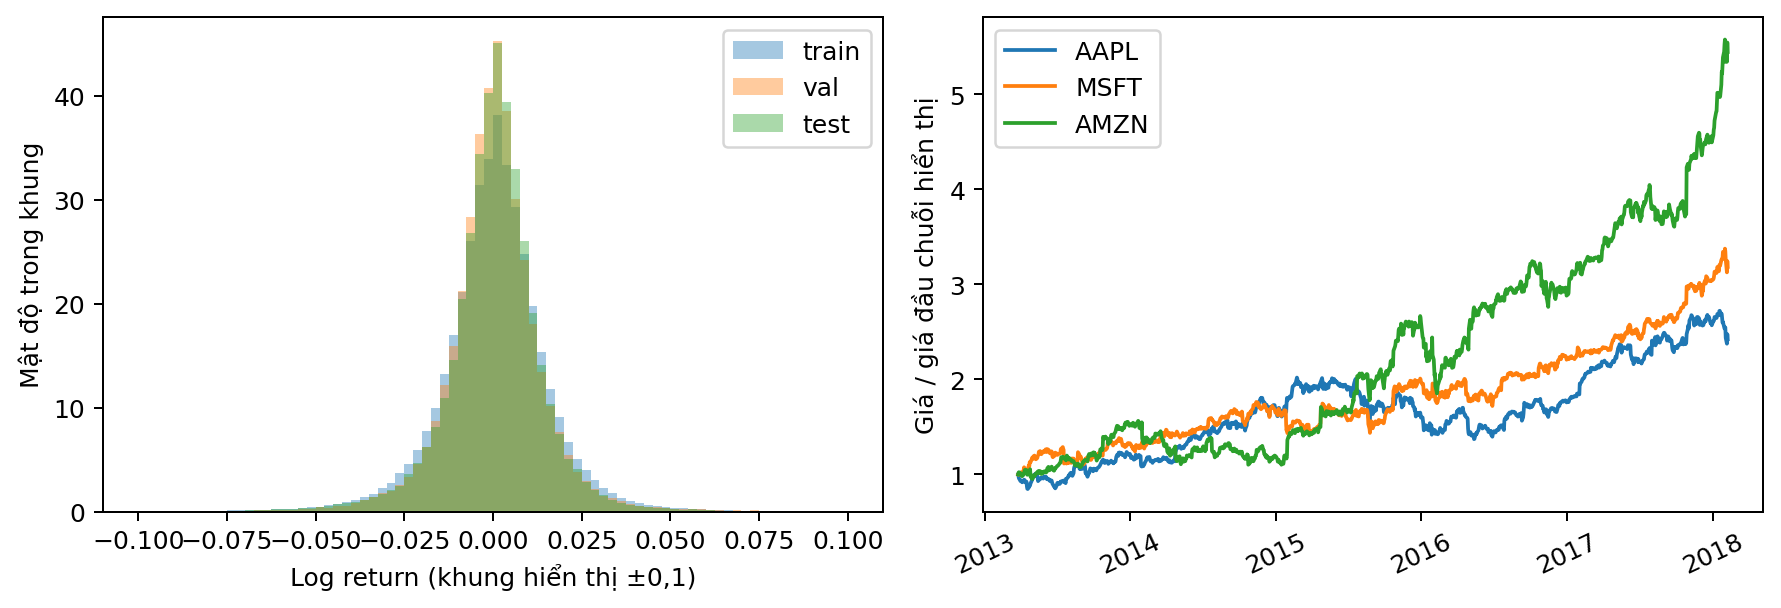

In [5]:
display(Image(filename=str(ROOT/'figures/stock_exploration.png')))

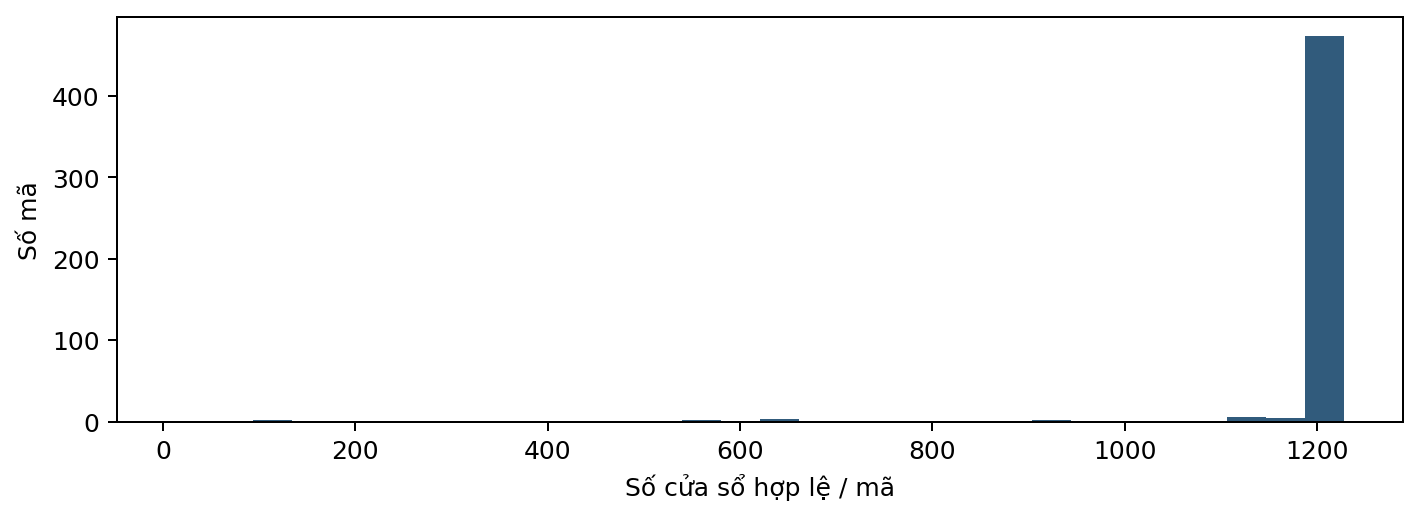

In [6]:
display(Image(filename=str(ROOT/'figures/stock_windows.png')))

## 4. Giới hạn
Dự đoán một phiên quan sát tiếp theo, dùng thông tin đến phiên trước. Dữ liệu lịch sử, thành phần chỉ số và cách điều chỉnh giá giới hạn khả năng suy rộng.